# Titanic

## Cleaning and Preparing Dataframe

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

In [5]:
df = pd.read_csv('titanic_train.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
(df.isnull().sum() / len(df)) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [8]:
df = df.drop(columns=["Cabin"])

In [9]:
df.head

<bound method NDFrame.head of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                     

In [10]:
median_age_female = df.loc[df["Sex"] == "female", "Age"].median()

In [11]:
df.loc[(df["Sex"] == "female") & (df["Age"].isnull()), "Age"] = median_age_female

In [12]:
median_age_male = df.loc[df["Sex"] == "male", "Age"].median()

In [13]:
df.loc[(df["Sex"] == "male") & (df["Age"].isnull()), "Age"] = median_age_male

In [14]:
df["Age"].isnull().sum()

np.int64(0)

In [15]:
most_common_embarked = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(most_common_embarked)

In [16]:
df["Embarked"].isnull().sum()

np.int64(0)

## Step 8

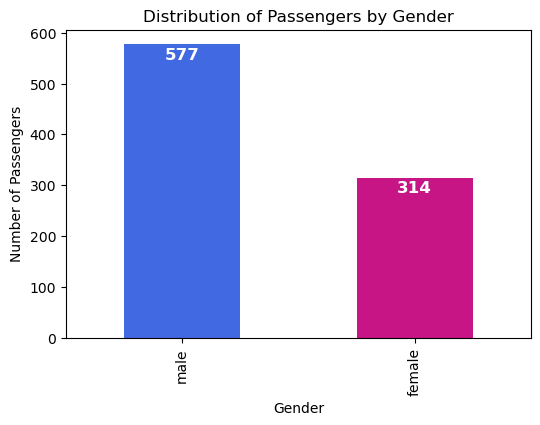

In [17]:
ax = df["Sex"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Distribution of Passengers by Gender",
color=["royalblue", "mediumvioletred"])

plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

# Add the values inside the bars
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() - 20,
        str(int(bar.get_height())),
        ha="center",
        va="center",
        color="white",
        fontsize=12,
        fontweight="bold"
    )

plt.show()

## Step 9

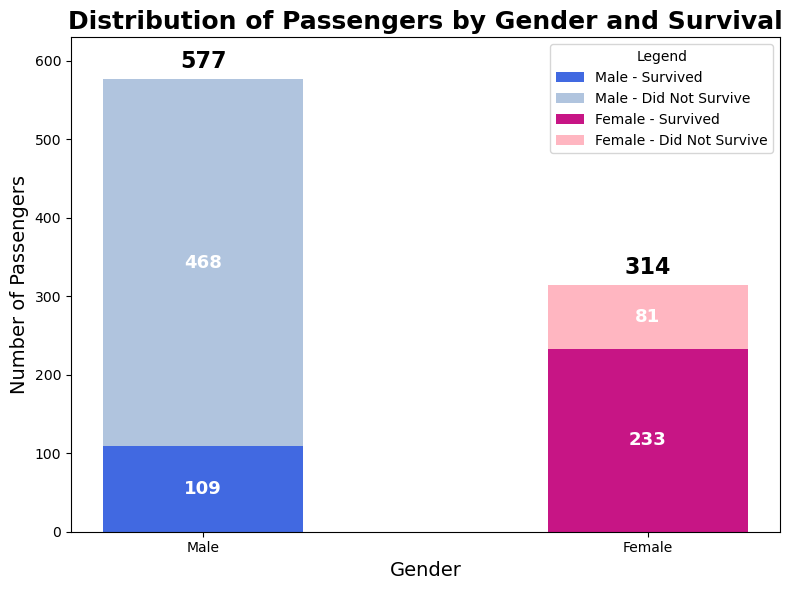

In [18]:
# Create the data
male = df[df["Sex"] == "male"]["Survived"].value_counts().sort_index()
female = df[df["Sex"] == "female"]["Survived"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 6))

# Width of the bars
bar_width = 0.45


# Male
ax.bar(
    "Male",
    male[1],
    width=bar_width,
    color="royalblue"
)

ax.bar(
    "Male",
    male[0],
    width=bar_width,
    bottom=male[1],
    color="lightsteelblue"
)


# Female
ax.bar(
    "Female",
    female[1],
    width=bar_width,
    color="mediumvioletred"
)

ax.bar(
    "Female",
    female[0],
    width=bar_width,
    bottom=female[1],
    color="lightpink"
)


# Labels inside the bars
ax.text(0, male[1]/2, str(male[1]),
        ha="center", va="center",
        color="white", fontsize=13, fontweight="bold")

ax.text(0, male[1] + male[0]/2, str(male[0]),
        ha="center", va="center",
        color="white", fontsize=13, fontweight="bold")

ax.text(1, female[1]/2, str(female[1]),
        ha="center", va="center",
        color="white", fontsize=13, fontweight="bold")

ax.text(1, female[1] + female[0]/2, str(female[0]),
        ha="center", va="center",
        color="white", fontsize=13, fontweight="bold")


# Totals
ax.text(0, male.sum() + 8, str(male.sum()),
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold")

ax.text(1, female.sum() + 8, str(female.sum()),
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold")

# Leave space above the bars
ax.set_ylim(0, 630)


# Legend
legend = [
    Patch(facecolor="royalblue", label="Male - Survived"),
    Patch(facecolor="lightsteelblue", label="Male - Did Not Survive"),
    Patch(facecolor="mediumvioletred", label="Female - Survived"),
    Patch(facecolor="lightpink", label="Female - Did Not Survive")
]

ax.legend(handles=legend, title="Legend")

# Titles
plt.title("Distribution of Passengers by Gender and Survival",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Gender", fontsize=14)
plt.ylabel("Number of Passengers", fontsize=14)

plt.tight_layout()

plt.show()

## Step 10

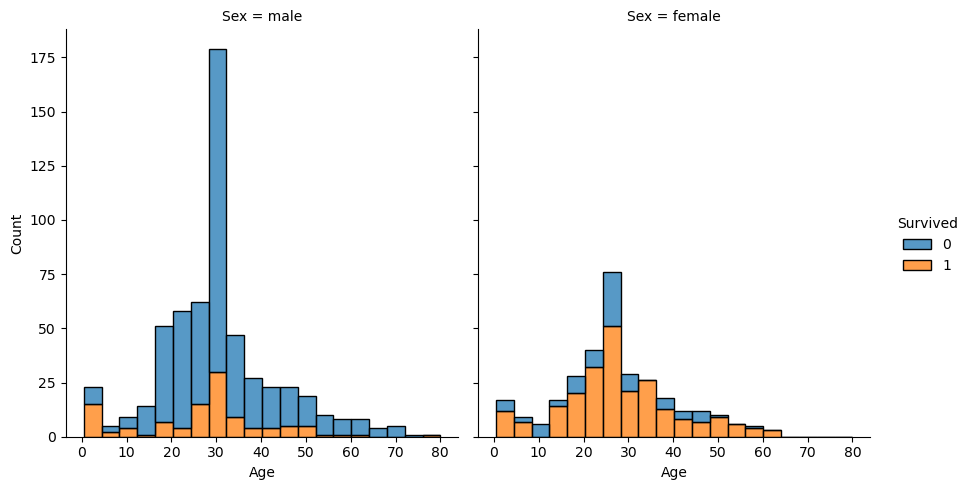

In [19]:
# Age distribution by gender and survival

sns.displot(
    data=df,
    x="Age",
    col="Sex",
    hue="Survived",
    multiple="stack",
    bins=20,
    height=5,
    aspect=0.9
)

plt.show()

## Step 11

In [20]:
df_corr = df.copy()
df_corr["Sex"] = df_corr["Sex"].map({"male": 0, "female": 1})

cols = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
corr_mtx = df_corr[cols].corr()
corr_mtx

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,0.543351,-0.073296,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.131900,-0.338056,0.083081,0.018443,-0.549500
Sex,0.543351,-0.131900,1.000000,-0.095256,0.114631,0.245489,0.182333
Age,-0.073296,-0.338056,-0.095256,1.000000,-0.236376,-0.176038,0.094161
SibSp,-0.035322,0.083081,0.114631,-0.236376,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,0.245489,-0.176038,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.182333,0.094161,0.159651,0.216225,1.000000


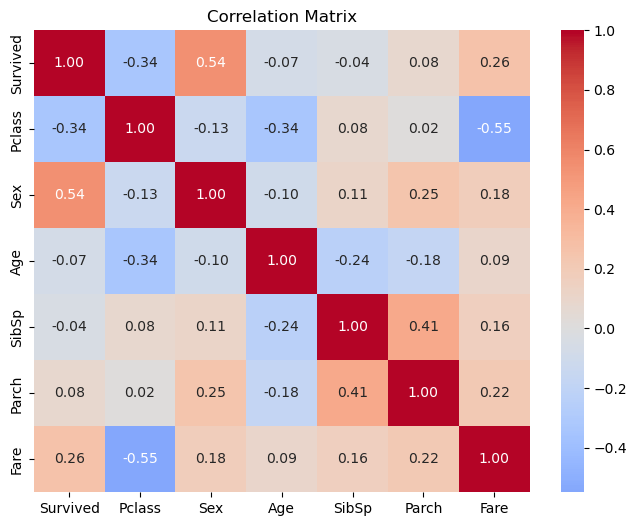

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_mtx, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Matrix")
plt.show()

## Step 12

In [22]:
base_rate = df["Survived"].mean()
print("Overall survival rate: %.1f%%" % (base_rate * 100))

Overall survival rate: 38.4%


### Q1. Who survived more, looking at sex and class together?

In [23]:
df.groupby("Sex")["Survived"].agg(["mean", "count"]).round(3)

,mean,count
Sex,,
female,0.742,314
male,0.189,577


In [24]:
df.groupby("Pclass")["Survived"].agg(["mean", "count"]).round(3)

,mean,count
Pclass,,
1,0.630,216
2,0.473,184
3,0.242,491


In [25]:
df.groupby(["Pclass", "Sex"])["Survived"].agg(["mean", "count"]).round(3)

mean  count
Pclass Sex                 
1      female  0.968     94
       male    0.369    122
2      female  0.921     76
       male    0.157    108
3      female  0.500    144
       male    0.135    347

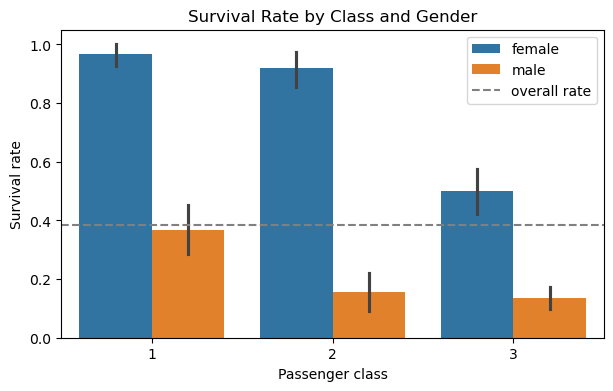

In [26]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex")
ax.axhline(df["Survived"].mean(), color="gray", linestyle="--", label="overall rate")
ax.set_title("Survival Rate by Class and Gender")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Survival rate")
ax.legend()
plt.show()

### Q2. Does age matter, and did the correlation table mislead us?

In [27]:
df["IsChild"] = df["Age"] < 16
df.groupby("IsChild")["Survived"].agg(["mean", "count"]).round(3)

,mean,count
IsChild,,
False,0.363,808
True,0.590,83


In [28]:
df.groupby(["IsChild", "Sex"])["Survived"].agg(["mean", "count"]).round(3)

mean  count
IsChild Sex                 
False   female  0.756    271
        male    0.164    537
True    female  0.651     43
        male    0.525     40

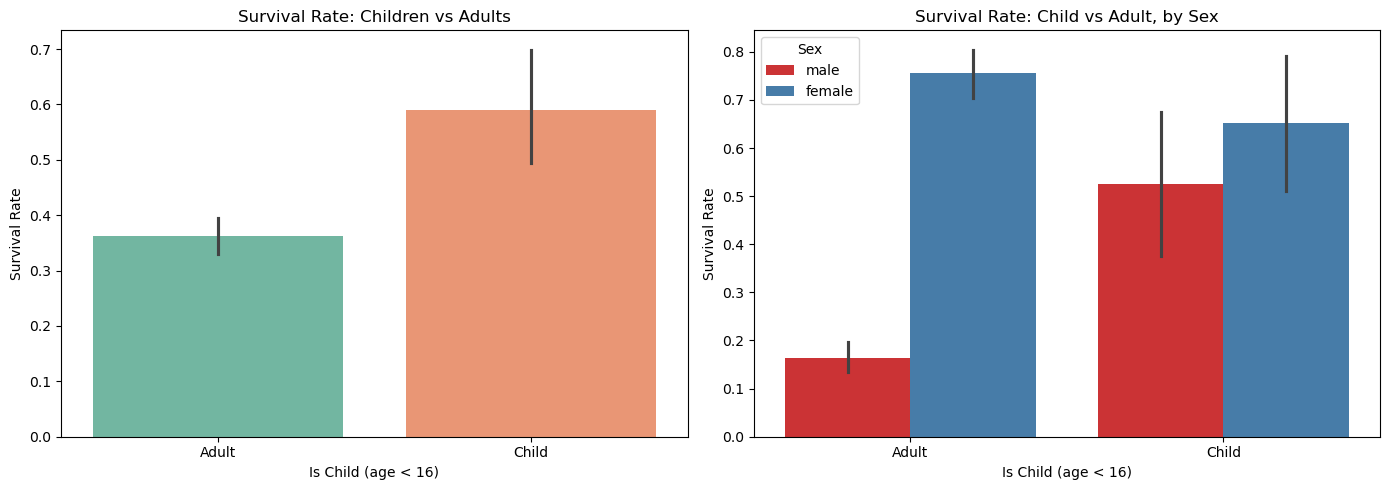

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x="IsChild", y="Survived", hue="IsChild", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Survival Rate: Children vs Adults")
axes[0].set_xlabel("Is Child (age < 16)")
axes[0].set_ylabel("Survival Rate")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Adult", "Child"])

sns.barplot(data=df, x="IsChild", y="Survived", hue="Sex", palette="Set1", ax=axes[1])
axes[1].set_title("Survival Rate: Child vs Adult, by Sex")
axes[1].set_xlabel("Is Child (age < 16)")
axes[1].set_ylabel("Survival Rate")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Adult", "Child"])
axes[1].legend(title="Sex")

plt.tight_layout()
plt.show()

### Q3. Does travelling alone or in a family change the odds?

In [29]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df.groupby("FamilySize")["Survived"].agg(["mean", "count"]).round(3)

,mean,count
FamilySize,,
1,0.304,537
2,0.553,161
3,0.578,102
4,0.724,29
5,0.200,15
6,0.136,22
7,0.333,12
8,0.000,6
11,0.000,7


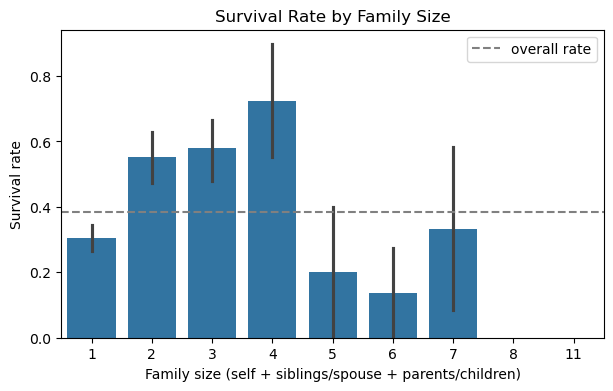

In [30]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=df, x="FamilySize", y="Survived")
ax.axhline(df["Survived"].mean(), color="gray", linestyle="--", label="overall rate")
ax.set_title("Survival Rate by Family Size")
ax.set_xlabel("Family size (self + siblings/spouse + parents/children)")
ax.set_ylabel("Survival rate")
ax.legend()
plt.show()

## Going further: predicting survival with machine learning

In [31]:
for col in ["Sex", "Pclass"]:
    table = pd.crosstab(df[col], df["Survived"])
    chi2, p, dof, _ = chi2_contingency(table)
    print(f"{col} vs Survived: chi2 = {chi2:.1f}, p = {p:.2e}")

Sex vs Survived: chi2 = 260.7, p = 1.20e-58
Pclass vs Survived: chi2 = 102.9, p = 4.55e-23


In [32]:
if "FamilySize" not in df.columns:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "FamilySize"]].copy()
X["Sex"] = X["Sex"].map({"male": 0, "female": 1})
X["Embarked"] = X["Embarked"].map({"S": 0, "C": 1, "Q": 2})
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape[0], " Test:", X_test.shape[0])

Train: 712  Test: 179


In [33]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

results = []
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    results.append({
        "model": name,
        "accuracy": round(accuracy_score(y_test, pred), 3),
        "precision": round(precision_score(y_test, pred), 3),
        "recall": round(recall_score(y_test, pred), 3),
        "f1": round(f1_score(y_test, pred), 3),
    })

pd.DataFrame(results)

,model,accuracy,precision,recall,f1
0,Logistic Regression,0.810,0.797,0.681,0.734
1,Decision Tree,0.793,0.808,0.609,0.694
2,Random Forest,0.804,0.758,0.725,0.741


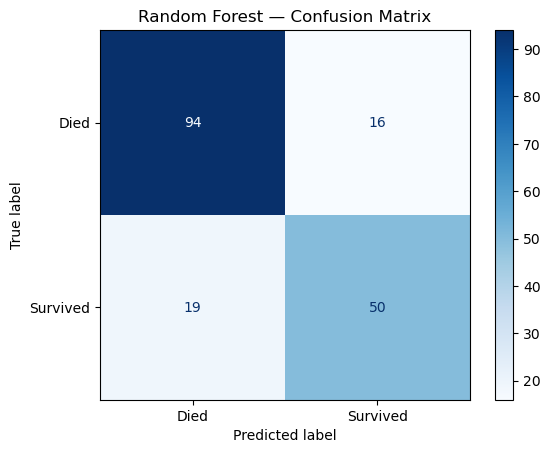

In [34]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test, predictions["Random Forest"]),
    display_labels=["Died", "Survived"]
).plot(cmap="Blues")
plt.title("Random Forest — Confusion Matrix")
plt.show()

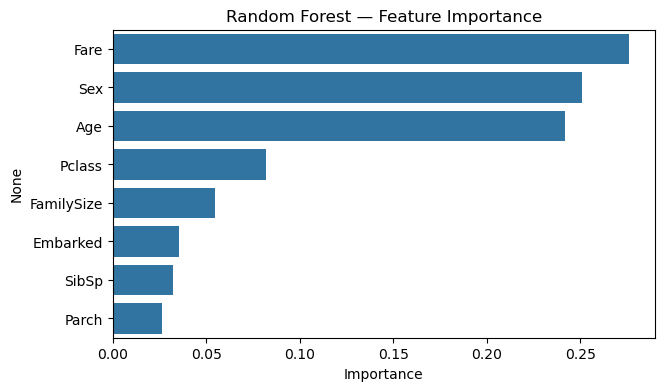

Fare          0.276
Sex           0.251
Age           0.242
Pclass        0.082
FamilySize    0.055
Embarked      0.035
SibSp         0.032
Parch         0.027
dtype: float64

In [35]:
importance = pd.Series(
    models["Random Forest"].feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.show()
importance.round(3)

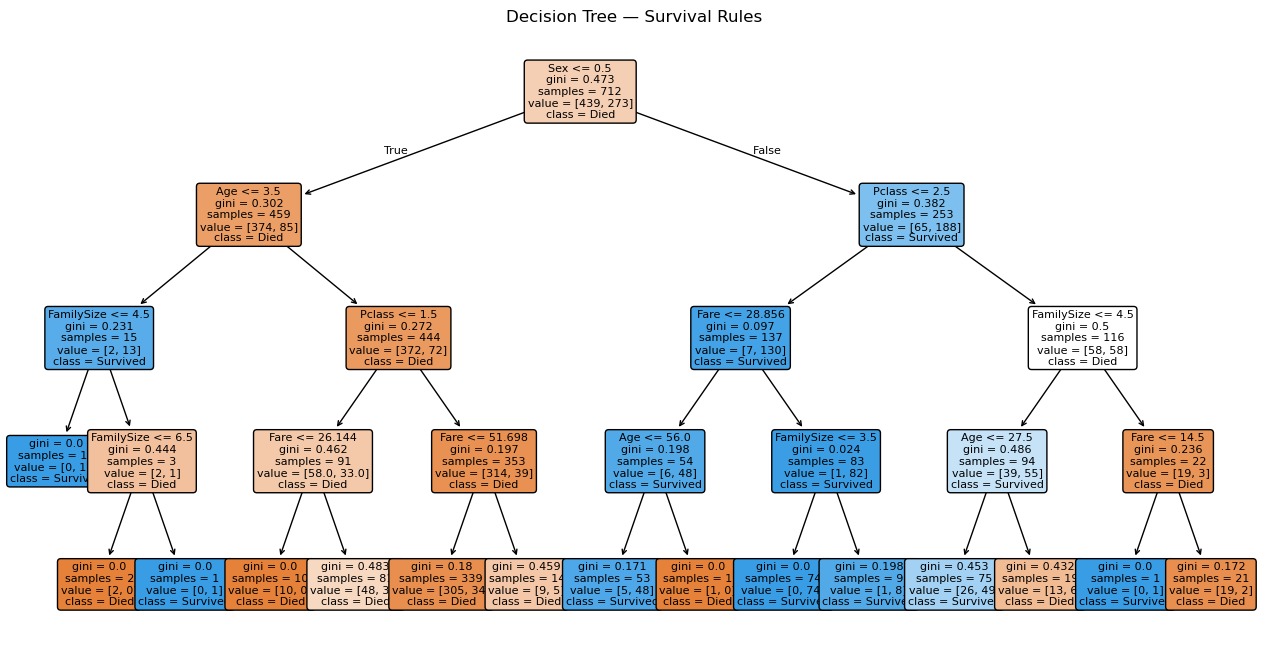

In [36]:
plt.figure(figsize=(16, 8))
plot_tree(models["Decision Tree"], feature_names=list(X.columns),
          class_names=["Died", "Survived"], filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree — Survival Rules")
plt.show()